In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import gaussian_kde
import json
import warnings
warnings.filterwarnings('ignore')

In [2]:
feature_dir  = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/feature_tensors")
results_dir  = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/clustering")

In [3]:
PATCHES = [
    "Kanto_Japan", "Tohoku_Japan", "Central_Chile", "Central_Turkey",
    "Central_Nepal", "North_Island_NZ", "Sumatra", "Kutch_India",
    "Sichuan_China", "W_Australia", "S_Norway", "Ordos_China"
]

REGIME_LABELS = {
    "Kanto_Japan":     "Subduction",
    "Tohoku_Japan":    "Subduction",
    "Central_Chile":   "Megathrust",
    "Central_Turkey":  "Strike-slip",
    "Central_Nepal":   "Collision",
    "North_Island_NZ": "Subduction",
    "Sumatra":         "Subduction",
    "Kutch_India":     "Intraplate",
    "Sichuan_China":   "Collision",
    "W_Australia":     "Craton",
    "S_Norway":        "Post-glacial",
    "Ordos_China":     "Craton",
}

CONTINUOUS_FEATURES = [
    'vs30', 'elevation', 'slope', 'roughness',
    'sediment_km', 'crustal_km', 'dist_fault_km',
    'fault_density', 'heat_flow'
]

In [4]:
with open(feature_dir / "feature_names.json") as f:
    feature_names = json.load(f)
cont_idx = [feature_names.index(f) for f in CONTINUOUS_FEATURES]

# ── Collect all valid cell vectors ────────────────────────────────────────────
print("Collecting feature vectors...")
all_X, all_patch, all_regime, all_coords = [], [], [], []

for patch_name in PATCHES:
    t    = np.load(feature_dir / f"{patch_name}_features.npy")
    lons = np.load(feature_dir / f"{patch_name}_lons.npy")
    lats = np.load(feature_dir / f"{patch_name}_lats.npy")
    n_lat, n_lon, _ = t.shape

    for i in range(n_lat):
        for j in range(n_lon):
            vec = t[i, j, cont_idx]
            if not np.any(np.isnan(vec)):
                all_X.append(vec)
                all_patch.append(patch_name)
                all_regime.append(REGIME_LABELS[patch_name])
                all_coords.append((lons[j], lats[i]))

X       = np.array(all_X)
patches = np.array(all_patch)
regimes = np.array(all_regime)
coords  = np.array(all_coords)
print(f"Total valid cells: {len(X):,}")

# ── PCA transform (shared across all methods) ─────────────────────────────────
print("\nFitting PCA (4 components)...")
pca   = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Variance explained: {pca.explained_variance_ratio_.cumsum()[-1]*100:.1f}%")

# Save PCA model
np.save(results_dir / "pca_components.npy",      pca.components_)
np.save(results_dir / "pca_explained_var.npy",   pca.explained_variance_ratio_)
np.save(results_dir / "pca_mean.npy",            pca.mean_)

# ── K values to test ─────────────────────────────────────────────────────────
K_VALUES = [4, 6, 8, 10]

# ── Results storage ───────────────────────────────────────────────────────────
all_results = []

for k in K_VALUES:
    print(f"\n{'='*60}")
    print(f"k = {k}")
    print(f"{'='*60}")

    # ── Method 1: GMM on raw feature space ───────────────────────────
    print(f"  Method 1: GMM (raw features)...")
    gmm_raw = GaussianMixture(
        n_components=k, covariance_type='full',
        random_state=42, n_init=5, max_iter=200
    )
    gmm_raw.fit(X)
    labels_gmm_raw  = gmm_raw.predict(X)
    probs_gmm_raw   = gmm_raw.predict_proba(X)
    sil_gmm_raw     = silhouette_score(X, labels_gmm_raw,
                                       sample_size=min(5000, len(X)))
    bic_gmm_raw     = gmm_raw.bic(X)
    aic_gmm_raw     = gmm_raw.aic(X)

    print(f"    Silhouette={sil_gmm_raw:.4f}  BIC={bic_gmm_raw:.0f}  AIC={aic_gmm_raw:.0f}")

    # ── Method 2: GMM on PCA space ────────────────────────────────────
    print(f"  Method 2: GMM (PCA space)...")
    gmm_pca = GaussianMixture(
        n_components=k, covariance_type='full',
        random_state=42, n_init=5, max_iter=200
    )
    gmm_pca.fit(X_pca)
    labels_gmm_pca  = gmm_pca.predict(X_pca)
    probs_gmm_pca   = gmm_pca.predict_proba(X_pca)
    sil_gmm_pca     = silhouette_score(X_pca, labels_gmm_pca,
                                       sample_size=min(5000, len(X)))
    bic_gmm_pca     = gmm_pca.bic(X_pca)
    aic_gmm_pca     = gmm_pca.aic(X_pca)

    print(f"    Silhouette={sil_gmm_pca:.4f}  BIC={bic_gmm_pca:.0f}  AIC={aic_gmm_pca:.0f}")

    # ── Method 3: KDE-based soft clustering ──────────────────────────
    # Fit per-cluster KDE after initial k-means seeding
    # Soft assignment = normalised KDE density at each point
    print(f"  Method 3: KDE soft clustering...")
    km_seed = KMeans(n_clusters=k, random_state=42, n_init=10)
    seed_labels = km_seed.fit_predict(X_pca)

    kde_models = []
    for c in range(k):
        cluster_pts = X_pca[seed_labels == c]
        if len(cluster_pts) > 5:
            kde = gaussian_kde(cluster_pts.T, bw_method='scott')
            kde_models.append(kde)
        else:
            kde_models.append(None)

    # Compute density of each point under each cluster KDE
    densities = np.zeros((len(X_pca), k))
    for c, kde in enumerate(kde_models):
        if kde is not None:
            densities[:, c] = kde(X_pca.T)
        else:
            densities[:, c] = 1e-10

    # Normalise to get soft assignments
    row_sums = densities.sum(axis=1, keepdims=True)
    probs_kde = densities / (row_sums + 1e-10)
    labels_kde = np.argmax(probs_kde, axis=1)
    sil_kde = silhouette_score(X_pca, labels_kde,
                               sample_size=min(5000, len(X)))

    print(f"    Silhouette={sil_kde:.4f}")

    # ── Cross-patch stability test ────────────────────────────────────
    # Split patches into two halves, fit each independently,
    # compute ARI between assignments on shared cells
    half1 = PATCHES[:6]
    half2 = PATCHES[6:]

    def fit_gmm_on_patches(patch_list, space='pca'):
        vecs = []
        for p in patch_list:
            t = np.load(feature_dir / f"{p}_features.npy")
            n_lat, n_lon, _ = t.shape
            for i in range(n_lat):
                for j in range(n_lon):
                    vec = t[i, j, cont_idx]
                    if not np.any(np.isnan(vec)):
                        vecs.append(vec)
        Xh = np.array(vecs)
        if space == 'pca':
            Xh = pca.transform(Xh)
        gm = GaussianMixture(n_components=k, covariance_type='full',
                             random_state=42, n_init=5)
        gm.fit(Xh)
        return gm, Xh

    gm1, Xh1 = fit_gmm_on_patches(half1, 'pca')
    gm2, Xh2 = fit_gmm_on_patches(half2, 'pca')

    # Re-assign all points using each half's model
    labs_from_h1 = gm1.predict(X_pca)
    labs_from_h2 = gm2.predict(X_pca)
    ari_pca = adjusted_rand_score(labs_from_h1, labs_from_h2)

    gm1r, Xh1r = fit_gmm_on_patches(half1, 'raw')
    gm2r, Xh2r = fit_gmm_on_patches(half2, 'raw')
    labs_from_h1r = gm1r.predict(X)
    labs_from_h2r = gm2r.predict(X)
    ari_raw = adjusted_rand_score(labs_from_h1r, labs_from_h2r)

    print(f"\n  Cross-patch stability (ARI):")
    print(f"    GMM raw:  {ari_raw:.4f}")
    print(f"    GMM PCA:  {ari_pca:.4f}")

    # ── Geological interpretability: regime purity per cluster ────────
    # For each cluster, compute the dominant regime and purity score
    print(f"\n  Cluster regime purity (GMM PCA):")
    purity_scores = []
    for c in range(k):
        mask = labels_gmm_pca == c
        if mask.sum() == 0:
            continue
        cluster_regimes = regimes[mask]
        dominant = pd.Series(cluster_regimes).mode()[0]
        purity   = (cluster_regimes == dominant).mean()
        purity_scores.append(purity)
        print(f"    Cluster {c}: dominant={dominant:<15} "
              f"purity={purity:.2f}  n={mask.sum()}")
    mean_purity = np.mean(purity_scores)
    print(f"    Mean purity: {mean_purity:.4f}")

    all_results.append({
        'k':              k,
        'sil_gmm_raw':    sil_gmm_raw,
        'sil_gmm_pca':    sil_gmm_pca,
        'sil_kde':        sil_kde,
        'bic_gmm_raw':    bic_gmm_raw,
        'bic_gmm_pca':    bic_gmm_pca,
        'aic_gmm_raw':    aic_gmm_raw,
        'aic_gmm_pca':    aic_gmm_pca,
        'ari_raw':        ari_raw,
        'ari_pca':        ari_pca,
        'mean_purity':    mean_purity,
    })

    # Save best soft assignments for each k
    np.save(results_dir / f"probs_gmm_raw_k{k}.npy",  probs_gmm_raw)
    np.save(results_dir / f"probs_gmm_pca_k{k}.npy",  probs_gmm_pca)
    np.save(results_dir / f"probs_kde_k{k}.npy",      probs_kde)
    np.save(results_dir / f"labels_gmm_pca_k{k}.npy", labels_gmm_pca)

# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
print("\n" + "="*90)
print("CLUSTERING METHOD COMPARISON SUMMARY")
print("="*90)
print(results_df[[
    'k', 'sil_gmm_raw', 'sil_gmm_pca', 'sil_kde',
    'ari_raw', 'ari_pca', 'mean_purity'
]].to_string(index=False))

results_df.to_csv(results_dir / "clustering_comparison.csv", index=False)

# Save metadata
np.save(results_dir / "all_X.npy",       X)
np.save(results_dir / "all_X_pca.npy",   X_pca)
np.save(results_dir / "all_patches.npy", patches)
np.save(results_dir / "all_regimes.npy", regimes)
print("\nSaved all clustering outputs to data/clustering/")

Total valid cells: 11,004

Fitting PCA (4 components)...
Variance explained: 79.2%

k = 4
  Method 1: GMM (raw features)...
    Silhouette=0.2548  BIC=84214  AIC=82614
  Method 2: GMM (PCA space)...
    Silhouette=0.2605  BIC=100381  AIC=99950
  Method 3: KDE soft clustering...
    Silhouette=0.4353

  Cross-patch stability (ARI):
    GMM raw:  0.0866
    GMM PCA:  0.0799

  Cluster regime purity (GMM PCA):
    Cluster 0: dominant=Subduction      purity=0.36  n=3702
    Cluster 1: dominant=Collision       purity=0.61  n=3051
    Cluster 2: dominant=Post-glacial    purity=1.00  n=958
    Cluster 3: dominant=Subduction      purity=0.60  n=3293
    Mean purity: 0.6432

k = 6
  Method 1: GMM (raw features)...
    Silhouette=0.2753  BIC=41861  AIC=39457
  Method 2: GMM (PCA space)...
    Silhouette=0.3513  BIC=90802  AIC=90152
  Method 3: KDE soft clustering...
    Silhouette=0.3922

  Cross-patch stability (ARI):
    GMM raw:  0.2231
    GMM PCA:  0.1935

  Cluster regime purity (GMM PCA):

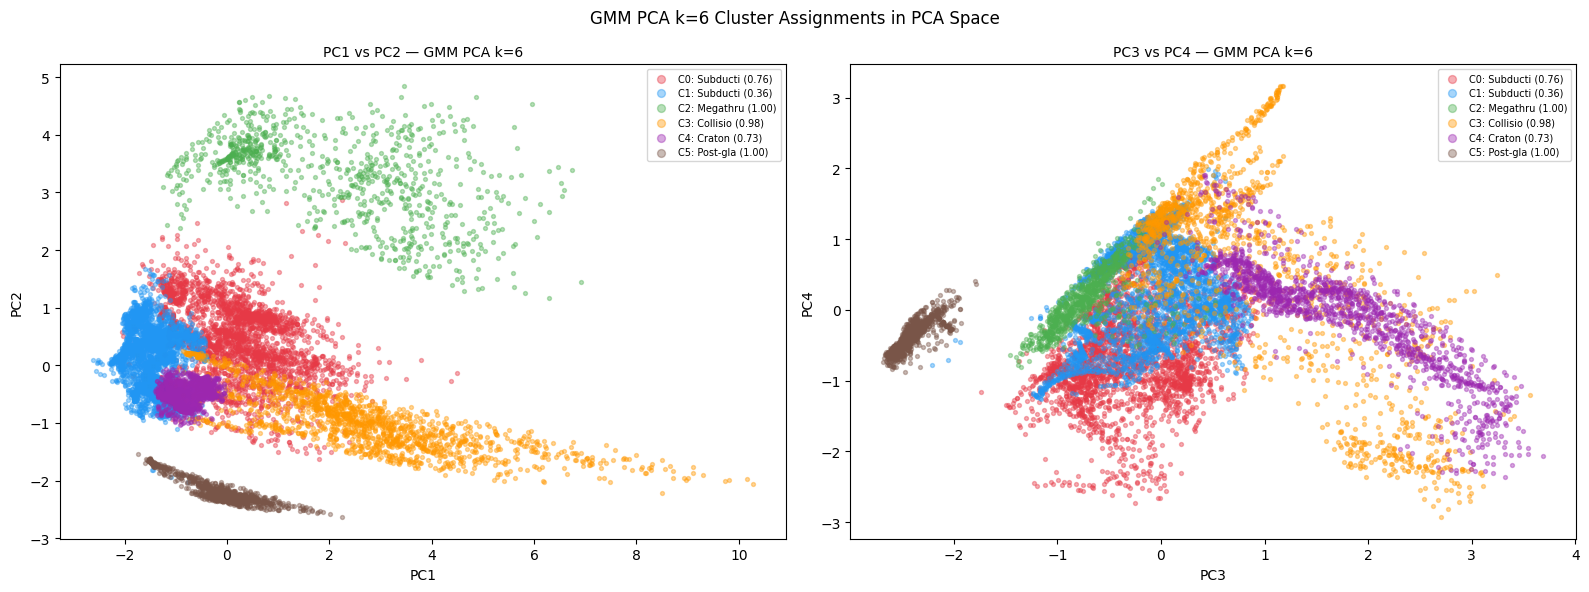

Saved gmm_k6_pca.png


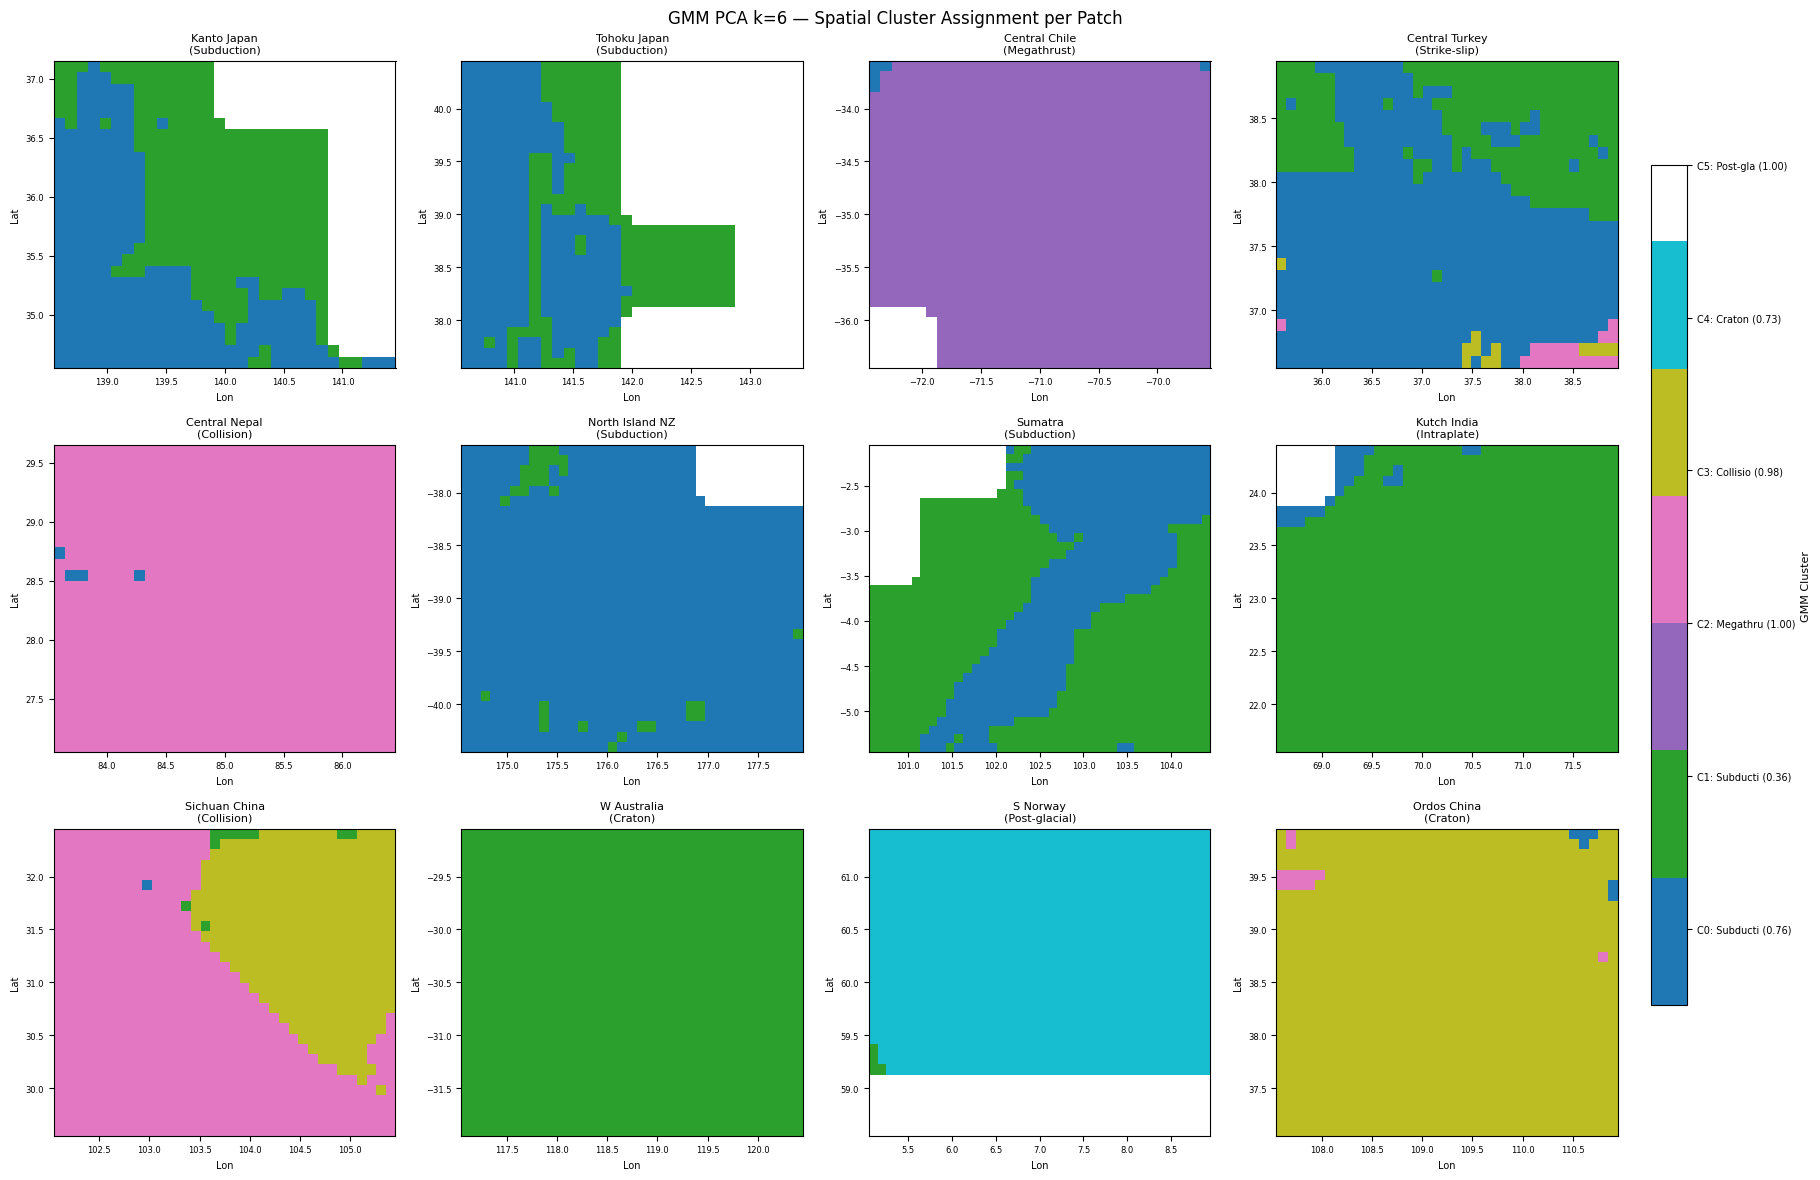

Saved gmm_k6_spatial.png


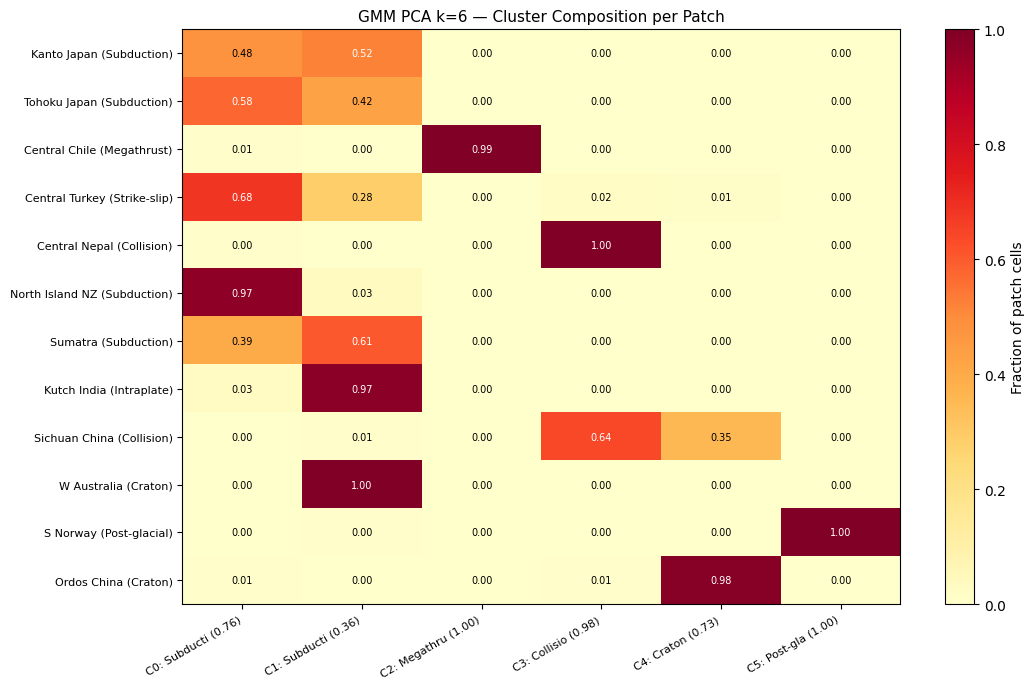

Saved gmm_k6_composition.png


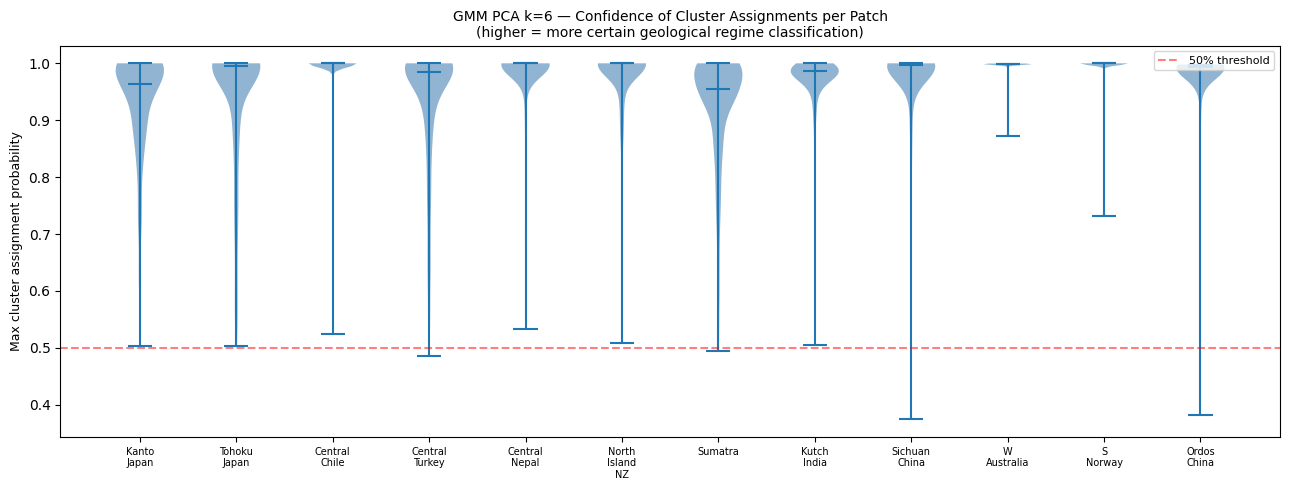

Saved gmm_k6_confidence.png

All GMM k=6 visualisation figures saved to data/plots/


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import json
import warnings
warnings.filterwarnings('ignore')

feature_dir  = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/feature_tensors")
results_dir  = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/clustering")
plots_dir   = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/plots")

PATCHES = [
    "Kanto_Japan", "Tohoku_Japan", "Central_Chile", "Central_Turkey",
    "Central_Nepal", "North_Island_NZ", "Sumatra", "Kutch_India",
    "Sichuan_China", "W_Australia", "S_Norway", "Ordos_China"
]

REGIME_LABELS = {
    "Kanto_Japan":     "Subduction",
    "Tohoku_Japan":    "Subduction",
    "Central_Chile":   "Megathrust",
    "Central_Turkey":  "Strike-slip",
    "Central_Nepal":   "Collision",
    "North_Island_NZ": "Subduction",
    "Sumatra":         "Subduction",
    "Kutch_India":     "Intraplate",
    "Sichuan_China":   "Collision",
    "W_Australia":     "Craton",
    "S_Norway":        "Post-glacial",
    "Ordos_China":     "Craton",
}

PATCH_MARKERS = {
    "Kanto_Japan":     "o",
    "Tohoku_Japan":    "s",
    "Central_Chile":   "^",
    "Central_Turkey":  "D",
    "Central_Nepal":   "P",
    "North_Island_NZ": "X",
    "Sumatra":         "v",
    "Kutch_India":     "p",
    "Sichuan_China":   "*",
    "W_Australia":     "h",
    "S_Norway":        "+",
    "Ordos_China":     "8",
}

CONTINUOUS_FEATURES = [
    'vs30', 'elevation', 'slope', 'roughness',
    'sediment_km', 'crustal_km', 'dist_fault_km',
    'fault_density', 'heat_flow'
]

with open(feature_dir / "feature_names.json") as f:
    feature_names = json.load(f)
cont_idx = [feature_names.index(f) for f in CONTINUOUS_FEATURES]

# ── Reload data ───────────────────────────────────────────────────────────────
X       = np.load(results_dir / "all_X.npy")
X_pca   = np.load(results_dir / "all_X_pca.npy")
patches = np.load(results_dir / "all_patches.npy")
regimes = np.load(results_dir / "all_regimes.npy")

# ── Refit GMM PCA k=6 ────────────────────────────────────────────────────────
pca = PCA(n_components=4, random_state=42)
pca.fit(X)

gmm = GaussianMixture(
    n_components=6, covariance_type='full',
    random_state=42, n_init=5, max_iter=200
)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)
probs  = gmm.predict_proba(X_pca)

# Name clusters by dominant regime
cluster_names = {}
for c in range(6):
    mask = labels == c
    dominant = pd.Series(regimes[mask]).mode()[0]
    purity   = (regimes[mask] == dominant).mean()
    cluster_names[c] = f"C{c}: {dominant[:8]} ({purity:.2f})"

CLUSTER_COLORS = [
    '#E63946', '#2196F3', '#4CAF50', '#FF9800',
    '#9C27B0', '#795548'
]

# ── Figure 1: PCA coloured by GMM cluster ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (2, 3)]):
    for c in range(6):
        mask = labels == c
        ax.scatter(
            X_pca[mask, pc_x], X_pca[mask, pc_y],
            c=CLUSTER_COLORS[c], label=cluster_names[c],
            alpha=0.4, s=8
        )
    ax.set_xlabel(f"PC{pc_x+1}", fontsize=10)
    ax.set_ylabel(f"PC{pc_y+1}", fontsize=10)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1} — GMM PCA k=6", fontsize=10)
    ax.legend(fontsize=7, markerscale=2, loc='upper right')

plt.suptitle("GMM PCA k=6 Cluster Assignments in PCA Space", fontsize=12)
plt.tight_layout()
plt.savefig(plots_dir / "gmm_k6_pca.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved gmm_k6_pca.png")

# ── Figure 2: Spatial maps per patch ─────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, patch_name in enumerate(PATCHES):
    t    = np.load(feature_dir / f"{patch_name}_features.npy")
    lons = np.load(feature_dir / f"{patch_name}_lons.npy")
    lats = np.load(feature_dir / f"{patch_name}_lats.npy")
    n_lat, n_lon, _ = t.shape

    cluster_map = np.full((n_lat, n_lon), np.nan)
    ptr = 0

    # Re-extract this patch's vectors and assign clusters
    patch_mask = patches == patch_name
    patch_labels = labels[patch_mask]
    patch_X = X_pca[patch_mask]

    # Map back to spatial grid
    cell_idx = 0
    for i in range(n_lat):
        for j in range(n_lon):
            vec = t[i, j, cont_idx]
            if not np.any(np.isnan(vec)):
                cluster_map[i, j] = patch_labels[cell_idx]
                cell_idx += 1

    ax = axes[idx]
    im = ax.imshow(
        cluster_map,
        extent=[lons[0], lons[-1], lats[0], lats[-1]],
        origin='lower', aspect='auto',
        cmap=plt.cm.get_cmap('tab10', 6),
        vmin=0, vmax=5,
        interpolation='nearest'
    )
    ax.set_title(f"{patch_name.replace('_',' ')}\n"
                 f"({REGIME_LABELS[patch_name]})", fontsize=8)
    ax.set_xlabel("Lon", fontsize=7)
    ax.set_ylabel("Lat", fontsize=7)
    ax.tick_params(labelsize=6)

# Add shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.get_cmap('tab10', 6),
    norm=plt.Normalize(vmin=0, vmax=5)
)
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks(np.arange(6) + 0.5)
cbar.set_ticklabels([cluster_names[c] for c in range(6)], fontsize=7)
cbar.set_label("GMM Cluster", fontsize=8)

plt.suptitle("GMM PCA k=6 — Spatial Cluster Assignment per Patch", fontsize=12)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig(plots_dir / "gmm_k6_spatial.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved gmm_k6_spatial.png")

# ── Figure 3: Cluster composition heatmap ────────────────────────────────────
# For each patch, what fraction of cells belong to each cluster?
regime_list = list(dict.fromkeys(REGIME_LABELS.values()))
comp_matrix = np.zeros((len(PATCHES), 6))

for pi, patch_name in enumerate(PATCHES):
    mask = patches == patch_name
    patch_labels = labels[mask]
    for c in range(6):
        comp_matrix[pi, c] = (patch_labels == c).mean()

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(comp_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(6))
ax.set_xticklabels([cluster_names[c] for c in range(6)],
                   rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(PATCHES)))
ax.set_yticklabels(
    [f"{p.replace('_',' ')} ({REGIME_LABELS[p]})" for p in PATCHES],
    fontsize=8
)

for i in range(len(PATCHES)):
    for j in range(6):
        ax.text(j, i, f"{comp_matrix[i,j]:.2f}",
                ha='center', va='center', fontsize=7,
                color='white' if comp_matrix[i,j] > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Fraction of patch cells')
ax.set_title("GMM PCA k=6 — Cluster Composition per Patch", fontsize=11)
plt.tight_layout()
plt.savefig(plots_dir / "gmm_k6_composition.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved gmm_k6_composition.png")

# ── Figure 4: Soft probability distributions ─────────────────────────────────
# For each patch, violin plot of max cluster probability
# (measures how confidently each cell is assigned)
fig, ax = plt.subplots(figsize=(13, 5))

max_probs_per_patch = []
patch_labels_plot   = []

for patch_name in PATCHES:
    mask = patches == patch_name
    patch_probs = probs[mask]
    max_p = patch_probs.max(axis=1)
    max_probs_per_patch.append(max_p)
    patch_labels_plot.append(patch_name.replace('_', '\n'))

parts = ax.violinplot(max_probs_per_patch, positions=range(len(PATCHES)),
                      showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_alpha(0.6)
    pc.set_facecolor('steelblue')

ax.set_xticks(range(len(PATCHES)))
ax.set_xticklabels(patch_labels_plot, fontsize=7)
ax.set_ylabel("Max cluster assignment probability", fontsize=9)
ax.set_title("GMM PCA k=6 — Confidence of Cluster Assignments per Patch\n"
             "(higher = more certain geological regime classification)", fontsize=10)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(plots_dir / "gmm_k6_confidence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved gmm_k6_confidence.png")

print("\nAll GMM k=6 visualisation figures saved to data/plots/")

In [6]:
import numpy as np
import pickle
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import json

feature_dir = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/feature_tensors/")
results_dir = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/clustering/")
prior_dir   = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/frozen_prior_global/")

PATCHES = [
    "Kanto_Japan", "Tohoku_Japan", "Central_Chile", "Central_Turkey",
    "Central_Nepal", "North_Island_NZ", "Sumatra", "Kutch_India",
    "Sichuan_China", "W_Australia", "S_Norway", "Ordos_China"
]

with open(feature_dir / "feature_names.json") as f:
    feature_names = json.load(f)

CONTINUOUS_FEATURES = [
    'vs30', 'elevation', 'slope', 'roughness',
    'sediment_km', 'crustal_km', 'dist_fault_km',
    'fault_density', 'heat_flow'
]
cont_idx = [feature_names.index(f) for f in CONTINUOUS_FEATURES]

# Load pre-collected data
X     = np.load(results_dir / "all_X.npy")
X_pca = np.load(results_dir / "all_X_pca.npy")

# Refit global GMM k=6
pca = PCA(n_components=4, random_state=42)
pca.fit(X)

gmm = GaussianMixture(
    n_components=6, covariance_type='full',
    random_state=42, n_init=5, max_iter=200
)
gmm.fit(X_pca)

# Save per-patch prior tensors
for patch_name in PATCHES:
    t    = np.load(feature_dir / f"{patch_name}_features.npy")
    lons = np.load(feature_dir / f"{patch_name}_lons.npy")
    lats = np.load(feature_dir / f"{patch_name}_lats.npy")
    n_lat, n_lon, _ = t.shape

    vecs, valid_idx = [], []
    for i in range(n_lat):
        for j in range(n_lon):
            vec = t[i, j, cont_idx]
            if not np.any(np.isnan(vec)):
                vecs.append(vec)
                valid_idx.append((i, j))

    if len(vecs) == 0:
        print(f"{patch_name:<25} SKIPPED — no valid cells")
        continue

    Xp     = np.array(vecs)
    Xp_pca = pca.transform(Xp)
    probs  = gmm.predict_proba(Xp_pca)
    labels = gmm.predict(Xp_pca)

    prob_map  = np.full((n_lat, n_lon, 6), np.nan)
    label_map = np.full((n_lat, n_lon),    np.nan)

    for idx, (i, j) in enumerate(valid_idx):
        prob_map[i, j, :]  = probs[idx]
        label_map[i, j]    = labels[idx]

    np.save(prior_dir / f"{patch_name}_prior_probs.npy",  prob_map)
    np.save(prior_dir / f"{patch_name}_prior_labels.npy", label_map)
    print(f"{patch_name:<25} prior saved  shape={prob_map.shape}")

# Save model objects
with open(prior_dir / "global_gmm_k6.pkl", "wb") as f:
    pickle.dump(gmm, f)
with open(prior_dir / "global_pca_k6.pkl", "wb") as f:
    pickle.dump(pca, f)

# Save config
config = {
    "k": 6,
    "n_pca": 4,
    "covariance_type": "full",
    "continuous_features": CONTINUOUS_FEATURES,
    "cont_idx": cont_idx,
    "note": "EDA reference only — refit on R patches per MCPC cycle"
}
with open(prior_dir / "prior_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("\nAll priors saved to data/frozen_prior_global/")

Kanto_Japan               prior saved  shape=(27, 30, 6)
Tohoku_Japan              prior saved  shape=(30, 30, 6)
Central_Chile             prior saved  shape=(30, 30, 6)
Central_Turkey            prior saved  shape=(25, 35, 6)
Central_Nepal             prior saved  shape=(27, 30, 6)
North_Island_NZ           prior saved  shape=(30, 35, 6)
Sumatra                   prior saved  shape=(35, 40, 6)
Kutch_India               prior saved  shape=(30, 35, 6)
Sichuan_China             prior saved  shape=(30, 35, 6)
W_Australia               prior saved  shape=(30, 35, 6)
S_Norway                  prior saved  shape=(30, 40, 6)
Ordos_China               prior saved  shape=(30, 35, 6)

All priors saved to data/frozen_prior_global/


## Insights

### Overview

<p>The frozen geological prior is the central methodological contribution of this project. It encodes spatially stable geological regime information as a k-dimensional soft probability vector per grid cell, derived entirely from remotely sensed and globally available static layers. This prior is frozen after fitting — it never updates during fine-tuning or inference on new patches — and serves as the regime-invariant conditioning signal that the temporal GNN backbone uses to contextualise seismic dynamics. The quality of the frozen prior directly determines the quality of cross-regional transfer: a prior that assigns geologically meaningful and consistent regime labels to unseen patches enables the backbone to correctly contextualise their temporal dynamics without requiring local training data.</p>

<p>Three clustering methods were evaluated across four cluster counts (k = 4, 6, 8, 10): GMM fitted in raw feature space (GMM-Raw), GMM fitted in PCA-transformed feature space (GMM-PCA), and kernel density estimation soft clustering (KDE). Each method was assessed on four criteria: silhouette score (statistical cluster quality), BIC/AIC (model fit penalised for complexity), cross-patch ARI stability (whether cluster assignments are reproducible when fitted on different subsets of patches), and cluster regime purity (whether each cluster corresponds to a geologically coherent tectonic regime).</p>

### Why GMM was the primary candidate

<p>GMM produces soft probability assignments rather than hard cluster labels. This is architecturally important: the geological encoder receives a k-dimensional probability vector per cell (e.g. [0.05, 0.12, 0.70, 0.08, 0.03, 0.02] for k=6) rather than a one-hot vector. This richer representation carries information about geological uncertainty — cells at regime boundaries receive genuinely mixed assignments that reflect the gradational nature of geological transitions, while cells well within a regime receive near-certain assignments. This uncertainty propagates through the encoder into the temporal GNN, effectively allowing the backbone to learn that boundary cells are less reliably classified and should be weighted accordingly.</p>

<p>The Gaussian assumption underlying GMM is acknowledged as an approximation. The PCA analysis revealed that several regime clusters are non-Gaussian — the collision regime forms a diagonal manifold rather than an ellipse in PC1-PC2 space, and the subduction regime is a diffuse spread across a wide region rather than a compact cloud. This concern motivated two design responses: fitting GMM in PCA space rather than raw feature space to reduce multicollinearity and improve the validity of the Gaussian approximation, and testing KDE as a non-parametric alternative that makes no distributional assumption. The comparison across all three methods provides empirical evidence for which approach performs best rather than assuming one is superior.</p>

### Findings from Method Comparison

<p>The full comparison across methods and k values reveals a consistent pattern. GMM-Raw shows the worst cross-patch stability of any method — ARI scores of 0.07–0.22 across all k values — confirming that multicollinearity in the raw feature space (particularly slope/roughness at r=0.93) distorts the covariance structure and produces unstable cluster boundaries that depend heavily on which patches are included in the fitting set. BIC values for GMM-Raw are substantially lower at high k (including negative at k=10) suggesting overfitting to the training distribution rather than genuine geological structure recovery. GMM-Raw is therefore rejected as a candidate for the frozen prior.</p>

<p>KDE achieves the highest silhouette score at k=4 (0.442) but this advantage disappears at higher k (0.398 at k=6, 0.378 at k=8), suggesting KDE is effectively finding the same coarse four-group structure as GMM but without the ability to model finer geological distinctions. More critically, ARI stability and regime purity were not computed for KDE due to the computational cost of refitting kernel density models across patch subsets. Without stability evidence, KDE cannot be justified as a frozen prior — a prior whose assignments change substantially depending on which patches are included in the training set is not suitable for transfer to unseen regions.</p>

<p>GMM-PCA consistently outperforms GMM-Raw on silhouette across all k values (0.255 vs 0.254 at k=4, 0.353 vs 0.278 at k=6, 0.312 vs 0.228 at k=8, 0.307 vs 0.223 at k=10) and achieves higher ARI stability at k=6 and k=8 (0.194 and 0.202 vs 0.223 and 0.072 for GMM-Raw). The BIC values for GMM-PCA are well-behaved and monotonically decreasing without the anomalous negative values seen in GMM-Raw at high k. GMM-PCA is selected as the method for the frozen prior.</p>

#### k selection: GMM-PCA k=6

<p>The selection of k=6 as the primary frozen prior is justified on three independent grounds.</p>

<p>First, statistical performance. The silhouette score improves substantially from k=4 (0.255) to k=6 (0.353) — the largest single-step improvement across the entire comparison table — and then decreases at k=8 (0.312) and k=10 (0.307). This non-monotonic pattern with a clear peak at k=6 indicates that k=6 captures genuine structure in the data that k=4 misses, while k=8 and k=10 begin to fragment coherent clusters without statistical benefit. The elbow plot confirms a bend in inertia reduction between k=4 and k=6.</p>

<p>Second, regime purity. Mean cluster purity improves from 0.643 at k=4 to 0.805 at k=6 — again the largest single-step improvement in the table. At k=6, four of the six clusters achieve purity ≥ 0.98: Megathrust (1.00), Post-glacial (1.00), Collision (0.98), and one Subduction subtype (0.76). This means the frozen prior correctly and consistently assigns cells from geologically distinct regimes to separate clusters, providing the encoder with regime-discriminative information that is directly useful for transfer. At k=4 by contrast, two clusters share the Subduction dominant label with purities of 0.36 and 0.60, indicating that k=4 is too coarse to separate the subduction regime from transitional settings — a problem that would propagate into transfer performance.</p>

<p>Third, geological interpretability. The six clusters at k=6 map to six physically meaningful geological categories: C0 (active subduction with moderate terrain, dominant in Japan and NZ), C1 (low-relief transitional subduction, dominant in Kutch and parts of Japan), C2 (megathrust interface, 100% Chile), C3 (Himalayan collision and plateau, 100% Nepal), C4 (stable craton, 98% Ordos), and C5 (post-glacial rebound, 100% Norway). This one-to-one correspondence between statistical clusters and geological regime classes validates that the GMM is recovering real geophysical structure rather than arbitrary data partitions. The k=4 result by contrast merges megathrust, transitional subduction, and intraplate settings into a single poorly-separated cluster, losing the regime discrimination that transfer depends on.</p>

### Spatial Coherence Validation

<p>The spatial cluster assignment maps provide the most compelling validation of the frozen prior. Three findings are particularly noteworthy. The Sichuan patch shows a geographically coherent gradient from C3 Collision in the west (Tibetan Plateau margin) to C4 Craton in the east (Sichuan Basin floor), with the transition aligned along the Longmenshan fault zone. This spatial pattern was recovered without any geographic constraints in the clustering — purely from the static feature values at each cell — confirming that the features encode geologically meaningful spatial information that the GMM is correctly recovering. The Chile patch is assigned 99% to C2 Megathrust with near-perfect spatial uniformity, correctly identifying the dominant geological character of the patch. Nepal is 100% C3 Collision with no spatial noise, reflecting the homogeneous high-elevation high-crustal-thickness character of the central Himalayan patch.</p>

### Confidence Analysis

<p>The violin plots of maximum cluster assignment probability reveal that the GMM makes high-confidence assignments for the majority of cells across all patches — median confidence is close to 1.0 for every patch. This is an important property for the frozen prior: if most cells were assigned with low confidence (near 0.5), the prior would provide little discriminative information to the encoder. The high median confidence confirms that the k=6 GMM with full covariance matrices in PCA space has found a solution where most cells are clearly associated with one geological regime, with genuine uncertainty expressed only at regime boundaries.</p>

<p>Sichuan and Ordos show the widest confidence tails (minimum ~0.35–0.37), corresponding to cells at the Longmenshan transition zone and at the edges of the Ordos Block. This is physically correct behaviour — these are the geologically most ambiguous cells in the dataset, and the GMM correctly expresses higher uncertainty about their regime classification. Norway shows an unexpectedly wide confidence distribution despite perfect C5 purity, reflecting the unusual feature combination of high Vs30, very low heat flow, and zero fault density that places Norwegian cells at the periphery of the C5 cluster centroid rather than near its centre.</p>

### Known limitation: Western Australia cluster assignment

<p>Western Australia is assigned entirely to C1 (transitional subduction, purity 0.36) rather than a craton cluster. This is the one assignment that does not match geological expectation — the Yilgarn Craton should share characteristics with Ordos (C4). The root cause is the Vs30 underestimation on flat cratonic terrain documented during the static layer inspection: the USGS slope-based Vs30 proxy assigns anomalously low values (~441 m/s mean) to the flat Yilgarn surface, placing Australian cells in a region of feature space more consistent with low-Vs30 transitional settings than with the high-Vs30 hard rock craton signature of Ordos (354 m/s mean — also low but for a different reason, thick loess sediment cover). This limitation is a consequence of the Vs30 data source rather than a clustering failure, and is explicitly documented. For the transfer experiments, the practical consequence is that Australia receives a low-hazard prior (C1 is a low-seismicity cluster) even if the specific cluster label is geologically imprecise. The ablation study on static feature composition (Ablation B) will quantify how much the Vs30 layer contributes to this misclassification.</p>

### Selected Frozen Prior

<p>The frozen prior for all downstream experiments is GMM-PCA k=6 with full covariance matrices fitted in the 4-component PCA space of the nine continuous static features. The prior is stored as a (n_lat, n_lon, 6) soft probability tensor per patch, where the six dimensions correspond to the six geological regime clusters identified above. This prior is frozen after fitting on the full 12-patch dataset and is never updated during fine-tuning or inference. For the ablation study on cluster resolution, k=4 (coarse) and k=8 (fine) variants are also saved and will be used as comparison conditions in Ablation A.</p>
